# Простой EDA данных E-CUP 2026

`label=1` — товар соответствует заявленной категории (`не бан`), `label=0` — не соответствует (`бан`).

## Что посмотрим

1. Размер и качество таблицы.
2. Баланс категорий и меток.
3. Объём и частые слова в текстах.
4. Количество и примеры изображений.
5. Точные текстовые дубли и конфликты меток.

In [31]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.feature_extraction.text import CountVectorizer

SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

In [32]:
# Ноутбук можно запустить из корня проекта или из папки experiments.
ROOT = Path.cwd()

if not (ROOT / "content/content_ecup/data.csv").is_file():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "content/content_ecup/data.csv"
IMAGES_DIR = ROOT / "content/content_ecup/images"

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Не найден файл: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# Это сохранённый индекс из CSV, для анализа он не нужен.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns="Unnamed: 0")

print(f"Загружено товаров: {len(df):,}".replace(",", " ") )
display(df.head(3))

Загружено товаров: 12 971


,id,name,description,category,label
0,0,Now CoQ-10 100 мг 50 капсул улучшает иммунитет,Состав В каждой капсуле биодобавки содержится 30 мг коэнзима Q10. Вспомогательные ингредиенты: р...,БАД,1
1,1,"Краски Холи, фестивальные (HOLI) набор 15 шт",Сделайте ваше уникальное мероприятие с набором конкурсных красок Холи! Наш цветной порошок (цвет...,Легковоспламеняющиеся,0
2,2,Мангал складной с шампурами KOLUNDROV Складень высокий разборный с сумкой для шашлыка казана и дачи,Мангал складной для шашлыка с 6 шампурами KOLUNDROV «Складень» в удобной сумке из огнеупорного в...,Легковоспламеняющиеся,0


### Основные колонки

| Колонка | Смысл |
|---|---|
| `id` | идентификатор товара и имя папки с изображениями |
| `name` | название карточки |
| `description` | описание карточки |
| `category` | проверяемая категория |
| `label` | 0 — бан, 1 — не бан |

## 1. Размер и качество таблицы

In [33]:
print(f"Строк: {df.shape[0]}")
print(f"Колонок: {df.shape[1]}")
print(f"Уникальных id: {df['id'].nunique()}")
print(f"Категории: {df['category'].unique().tolist()}")
print(f"Значения label: {sorted(df['label'].unique())}")

column_types = df.dtypes.astype(str).rename("dtype").to_frame()
display(column_types)

Строк: 12971
Колонок: 5
Уникальных id: 12971
Категории: ['БАД', 'Легковоспламеняющиеся']
Значения label: [np.int64(0), np.int64(1)]


,dtype
id,int64
name,str
description,str
category,str
label,int64


In [34]:
missing_values = df.isna().sum().reset_index()
missing_values.columns = ["column", "missing"]
missing_values["missing_percent"] = missing_values["missing"] / len(df) * 100

duplicate_ids = df["id"].duplicated().sum()
duplicate_rows = df.duplicated().sum()

display(missing_values)
print(f"Повторяющихся id: {duplicate_ids}")
print(f"Полностью одинаковых строк: {duplicate_rows}")

,column,missing,missing_percent
0,id,0,0.000000
1,name,0,0.000000
2,description,19,0.146481
3,category,0,0.000000
4,label,0,0.000000


Повторяющихся id: 0
Полностью одинаковых строк: 0


**Вывод.** В таблице 12 971 товар, все `id` уникальны. Названия заполнены полностью, отсутствует только 19 описаний. Категории и метки записаны единообразно, поэтому сложное исправление схемы не требуется.

## 2. Баланс категорий и меток

Метрика соревнования считается отдельно для двух категорий, поэтому распределение меток также смотрим отдельно.

In [35]:
class_counts = df.groupby(["category", "label"]).size().reset_index(name="count")
category_totals = df.groupby("category").size().reset_index(name="category_total")

class_counts = class_counts.merge(category_totals, on="category")
class_counts["share_percent"] = class_counts["count"] / class_counts["category_total"] * 100
class_counts["share_percent"] = class_counts["share_percent"].round(1)

display(class_counts)

,category,label,count,category_total,share_percent
0,БАД,0,1905,7469,25.5
1,БАД,1,5564,7469,74.5
2,Легковоспламеняющиеся,0,5304,5502,96.4
3,Легковоспламеняющиеся,1,198,5502,3.6


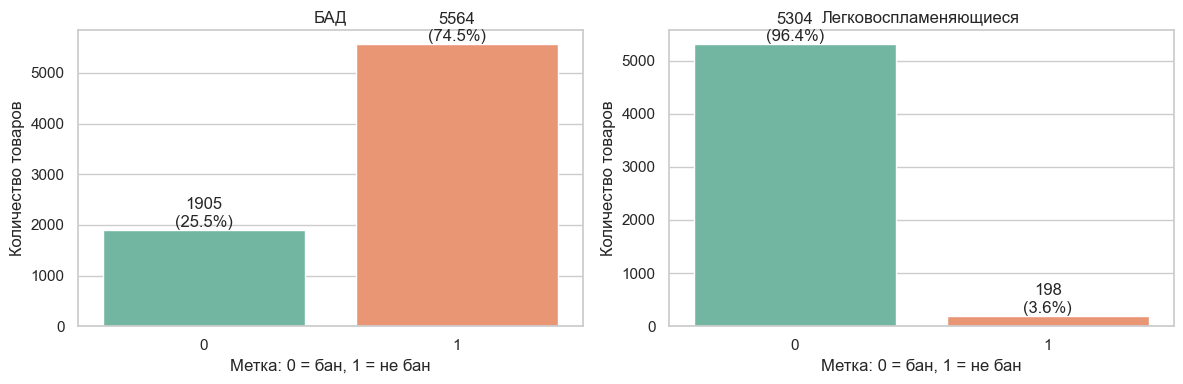

In [36]:
categories = df["category"].unique()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for index, category in enumerate(categories):
    ax = axes[index]
    part = class_counts[class_counts["category"] == category]

    sns.barplot(data=part, x="label", y="count", hue="label", palette="Set2", legend=False, ax=ax)
    ax.set_title(category)
    ax.set_xlabel("Метка: 0 = бан, 1 = не бан")
    ax.set_ylabel("Количество товаров")

    for bar, row in zip(ax.patches, part.itertuples()):
        label_text = f"{row.count}\n({row.share_percent:.1f}%)"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label_text, ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Вывод.** В категории «БАД» метка `1` встречается в 74,5% карточек, а в «Легковоспламеняющихся» — только в 3,6%. Для проверки модели нужны F1 по каждой категории и их среднее; train/validation должны сохранять все четыре сочетания `category × label`.

## 3. Текст

Сначала аккуратно удалим HTML-теги и лишние пробелы. Исходные колонки оставляем без изменений, очищенный текст записываем в новые колонки.

In [37]:
def clean_text_column(column):
    # Все операции выполняются сразу над всей pandas Series.
    cleaned = column.fillna("").astype(str)
    cleaned = cleaned.str.replace("&nbsp;", " ", regex=False)
    cleaned = cleaned.str.replace("&#34;", '"', regex=False)
    cleaned = cleaned.str.replace("&amp;", "&", regex=False)
    cleaned = cleaned.str.replace("&#39;", "'", regex=False)
    cleaned = cleaned.str.replace("&apos;", "'", regex=False)
    cleaned = cleaned.str.replace(r"<[^>]+>", " ", regex=True)
    cleaned = cleaned.str.replace(r"\s+", " ", regex=True)
    return cleaned.str.strip()

df["name_clean"] = clean_text_column(df["name"])
df["description_clean"] = clean_text_column(df["description"])
df["text"] = df["name_clean"] + " " + df["description_clean"]
df["text"] = df["text"].str.strip()

In [38]:
description_as_text = df["description"].fillna("").astype(str)
has_html = description_as_text.str.contains(r"<[^>]+>", regex=True)

text_quality = pd.Series({
    "пустых названий после очистки": int((df["name_clean"] == "").sum()),
    "пустых описаний после очистки": int((df["description_clean"] == "").sum()),
    "описаний с HTML-тегами": int(has_html.sum()),
})

display(text_quality.to_frame(name="count"))

,count
пустых названий после очистки,0
пустых описаний после очистки,19
описаний с HTML-тегами,7287


In [39]:
df["name_words"] = df["name_clean"].str.split().str.len()
df["description_words"] = df["description_clean"].str.split().str.len()
df["text_words"] = df["text"].str.split().str.len()

length_percentiles = df[["name_words", "description_words", "text_words"]].quantile([0.5, 0.9, 0.95, 0.99])
length_percentiles.index = ["50%", "90%", "95%", "99%"]
display(length_percentiles.round(1))

,name_words,description_words,text_words
50%,9.0,167.0,178.0
90%,16.0,359.0,368.0
95%,21.0,412.0,423.0
99%,26.0,610.0,622.3


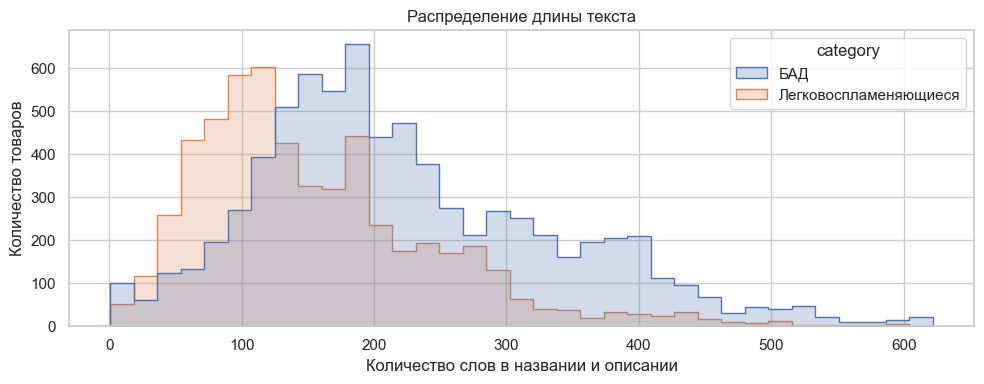

In [40]:
# Верхний 1% очень длинных карточек убираем только с графика, но не из данных.
plot_limit = df["text_words"].quantile(0.99)
plot_data = df[df["text_words"] <= plot_limit]

plt.figure(figsize=(10, 4))
sns.histplot(data=plot_data, x="text_words", hue="category", bins=35, element="step")
plt.title("Распределение длины текста")
plt.xlabel("Количество слов в названии и описании")
plt.ylabel("Количество товаров")
plt.tight_layout()
plt.show()

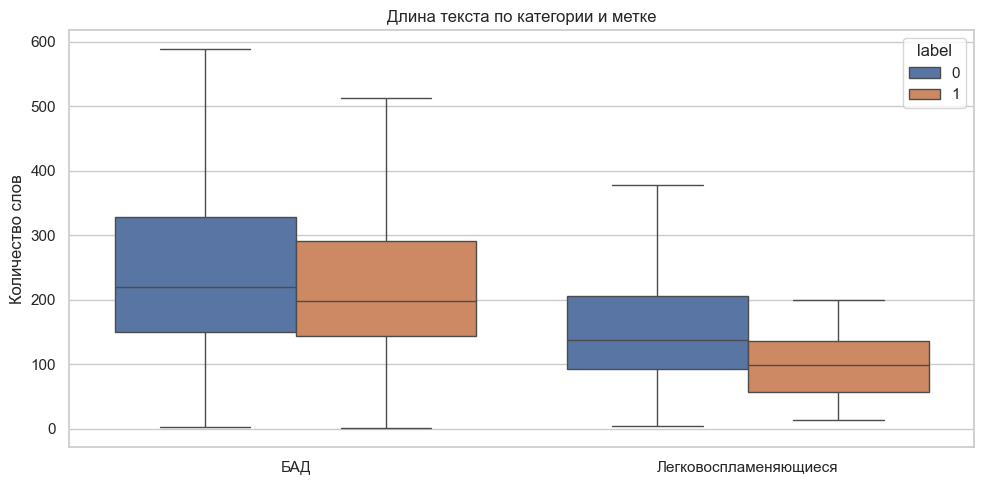

In [41]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="category", y="text_words", hue="label", showfliers=False)
plt.title("Длина текста по категории и метке")
plt.xlabel("")
plt.ylabel("Количество слов")
plt.legend(title="label")
plt.tight_layout()
plt.show()

**Вывод.** HTML встречается в 7 287 описаниях, поэтому базовая очистка нужна. Медианное название содержит 9 слов, описание — 167 слов, а весь текст — 178 слов. У 99% карточек не больше примерно 622 слов. Тексты БАД обычно длиннее; для модели с ограниченным контекстом позже нужно отдельно проверить обрезание.

### Частые слова

Считаем не все повторения слова, а число карточек, в которых оно встретилось. Так одно длинное описание не перетянет результат на себя.

In [42]:
STOP_WORDS = [
    "без", "более", "быть", "вам", "вас", "весь", "для", "его",
    "есть", "еще", "или", "как", "который", "может", "набор",
    "наш", "они", "она", "при", "также", "товар", "что", "это",
    "этот", "ваш", "свой", "все"
]

def get_top_words(texts, number_of_words=10):
    vectorizer = CountVectorizer(
        binary=True,
        stop_words=STOP_WORDS,
        token_pattern=r"(?u)\b[а-яёa-z][а-яёa-z0-9-]{2,}\b",
    )

    word_matrix = vectorizer.fit_transform(texts)
    word_counts = np.asarray(word_matrix.sum(axis=0)).flatten()

    result = pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "card_count": word_counts,
    })

    result = result.sort_values("card_count", ascending=False).head(number_of_words)
    return result

top_words_parts = []

for (category, label), group in df.groupby(["category", "label"]):
    group_words = get_top_words(group["text"])
    group_words["category"] = category
    group_words["label"] = label
    top_words_parts.append(group_words)

top_words = pd.concat(top_words_parts, ignore_index=True)
display(top_words.head(10))

,word,card_count,category,label
0,бад,974,БАД,0
1,способствует,948,БАД,0
2,организма,900,БАД,0
3,является,894,БАД,0
4,после,789,БАД,0
5,помогает,769,БАД,0
6,день,727,БАД,0
7,продукт,690,БАД,0
8,веществ,676,БАД,0
9,комплекс,674,БАД,0


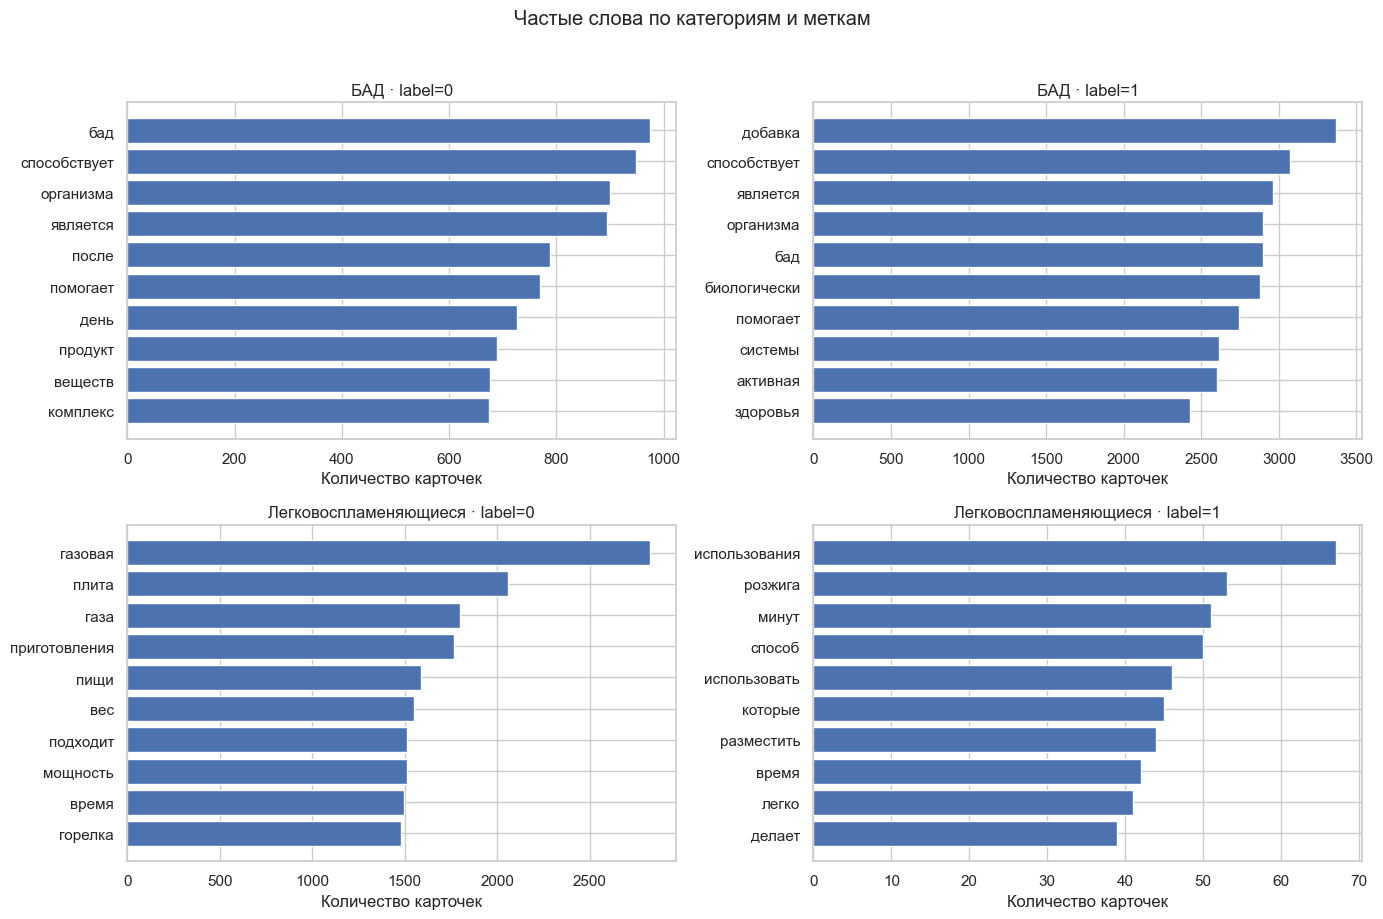

In [43]:
groups = list(top_words.groupby(["category", "label"]))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, ((category, label), group) in zip(axes.flatten(), groups):
    group = group.sort_values("card_count")
    ax.barh(group["word"], group["card_count"])
    ax.set_title(f"{category} · label={label}")
    ax.set_xlabel("Количество карточек")

plt.suptitle("Частые слова по категориям и меткам", y=1.02)
plt.tight_layout()
plt.show()

**Вывод.** Лексика четырёх групп заметно отличается, поэтому текст подходит для первого baseline. Частые слова — только подсказка для гипотез: их не нужно превращать в жёсткие правила без проверки на validation.

## 4. Изображения

Проверим покрытие изображениями и покажем случайные примеры. Полное чтение размеров и поиск одинаковых файлов пока не нужны для стартового EDA.

In [44]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

def get_image_paths(product_id):
    product_folder = IMAGES_DIR / str(product_id)

    if not product_folder.is_dir():
        return []

    paths = []
    for path in product_folder.iterdir():
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            paths.append(path)

    return sorted(paths)

image_counts = []

for product_id in df["id"]:
    paths = get_image_paths(product_id)
    image_counts.append(len(paths))

df["image_count"] = image_counts

In [45]:
image_summary = df.groupby(["category", "label"])["image_count"].agg(["count", "mean", "median", "min", "max"])
image_summary["mean"] = image_summary["mean"].round(2)

print(f"Всего изображений: {df['image_count'].sum()}")
print(f"Товаров без изображений: {(df['image_count'] == 0).sum()}")
display(image_summary)

Всего изображений: 49456
Товаров без изображений: 0


count  mean  median  min  max
category              label                               
БАД                   0       1905  4.27     5.0    1    5
                      1       5564  3.54     4.0    1    5
Легковоспламеняющиеся 0       5304  3.94     5.0    1    5
                      1        198  3.50     5.0    1    5

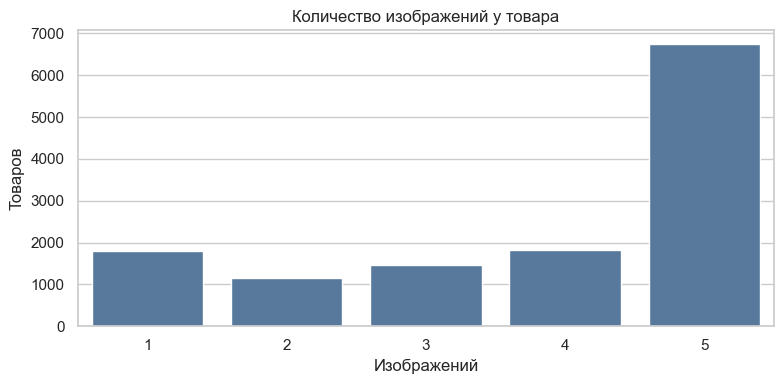

In [46]:
products_by_image_count = df["image_count"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=products_by_image_count.index, y=products_by_image_count.values, color="#4C78A8")
plt.title("Количество изображений у товара")
plt.xlabel("Изображений")
plt.ylabel("Товаров")
plt.tight_layout()
plt.show()

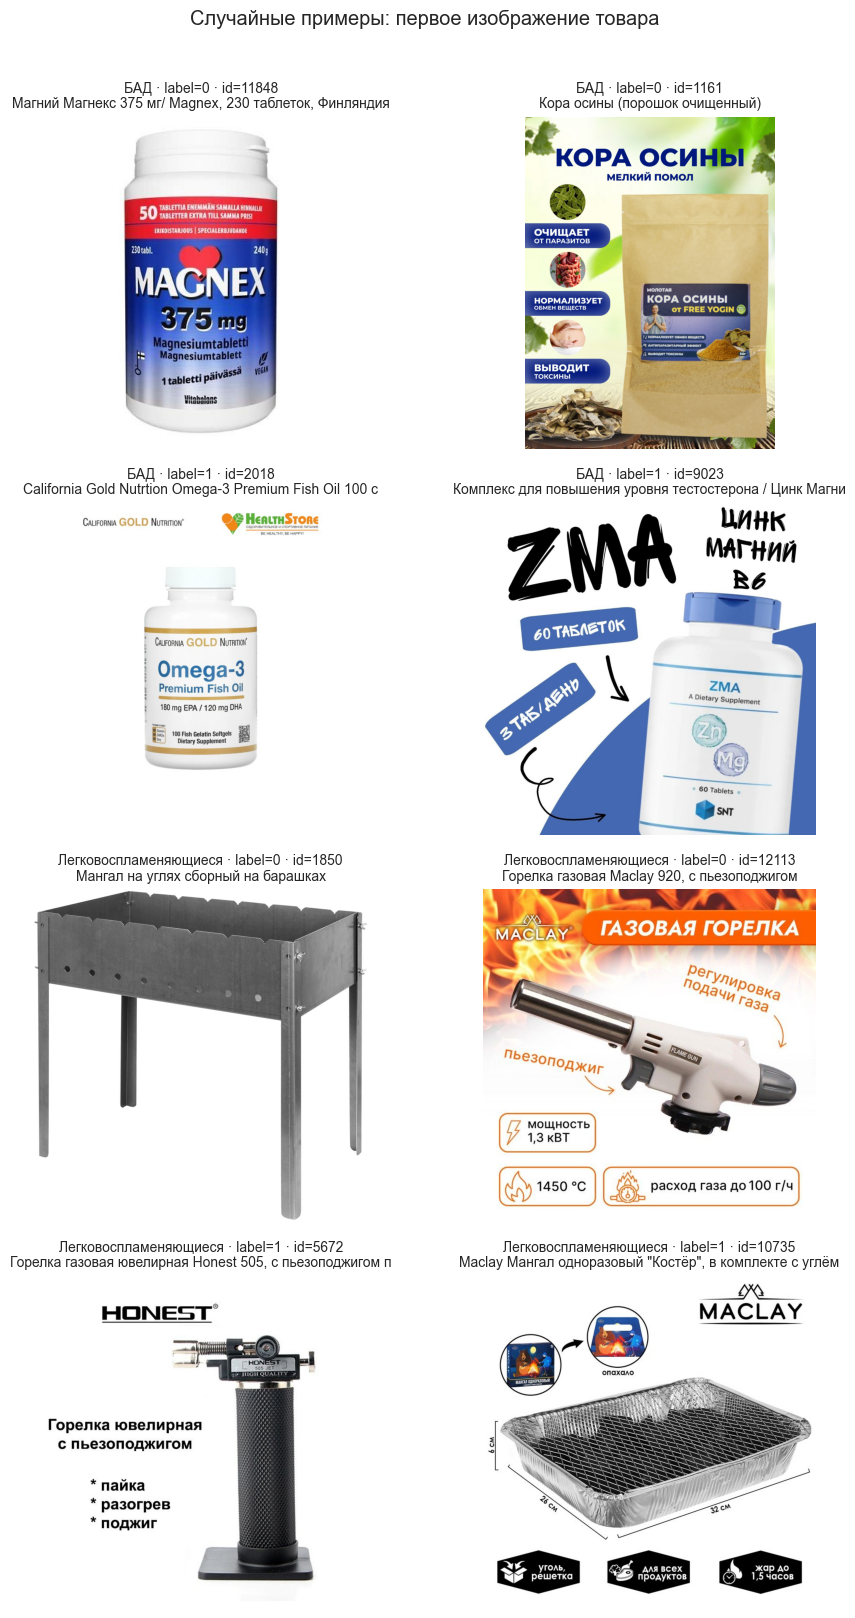

In [47]:
sample_parts = []

for _, group in df.groupby(["category", "label"]):
    sample_parts.append(group.sample(n=2, random_state=SEED))

image_sample = pd.concat(sample_parts, ignore_index=True)
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for ax, row in zip(axes.flatten(), image_sample.itertuples()):
    paths = get_image_paths(row.id)

    try:
        with Image.open(paths[0]) as image:
            ax.imshow(image.convert("RGB"))
    except Exception as error:
        ax.text(0.5, 0.5, f"Не удалось открыть изображение\n{error}", ha="center")

    short_name = row.name_clean[:55]
    ax.set_title(f"{row.category} · label={row.label} · id={row.id}\n{short_name}", fontsize=10)
    ax.axis("off")

plt.suptitle("Случайные примеры: первое изображение товара", y=1.01)
plt.tight_layout()
plt.show()

**Вывод.** В датасете 49 456 изображений. У каждого товара есть от 1 до 5 файлов, чаще всего — 5. Часть полезной информации видна на упаковке и этикетке, но вклад изображений лучше измерять только после фиксации текстового baseline.

## 5. Точные текстовые дубли

Для поиска дублей приведём текст к нижнему регистру, заменим `ё` на `е` и уберём пунктуацию. Эта версия текста нужна только для сравнения карточек, а не для модели.

In [48]:
# Нормализация также выполняется сразу над всей колонкой.
df["text_normalized"] = df["text"].str.lower()
df["text_normalized"] = df["text_normalized"].str.replace("ё", "е", regex=False)
df["text_normalized"] = df["text_normalized"].str.replace(r"[^0-9a-zа-я]+", " ", regex=True)
df["text_normalized"] = df["text_normalized"].str.replace(r"\s+", " ", regex=True)
df["text_normalized"] = df["text_normalized"].str.strip()

group_summary = df.groupby("text_normalized").agg(
    group_size=("id", "size"),
    label_count=("label", "nunique"),
    category_count=("category", "nunique"),
).reset_index()

duplicate_groups = group_summary[group_summary["group_size"] > 1].copy()
conflict_groups = duplicate_groups[duplicate_groups["label_count"] > 1].copy()

In [49]:
duplicate_texts = set(duplicate_groups["text_normalized"])
rows_in_duplicate_groups = df["text_normalized"].isin(duplicate_texts).sum()
groups_across_categories = (duplicate_groups["category_count"] > 1).sum()

duplicate_stats = pd.Series({
    "групп одинаковых текстов": len(duplicate_groups),
    "товаров в группах дублей": int(rows_in_duplicate_groups),
    "групп с разными label": len(conflict_groups),
    "групп из разных категорий": int(groups_across_categories),
    "максимальный размер группы": int(duplicate_groups["group_size"].max()),
})

display(duplicate_stats.to_frame(name="value"))

,value
групп одинаковых текстов,1802
товаров в группах дублей,5401
групп с разными label,55
групп из разных категорий,0
максимальный размер группы,58


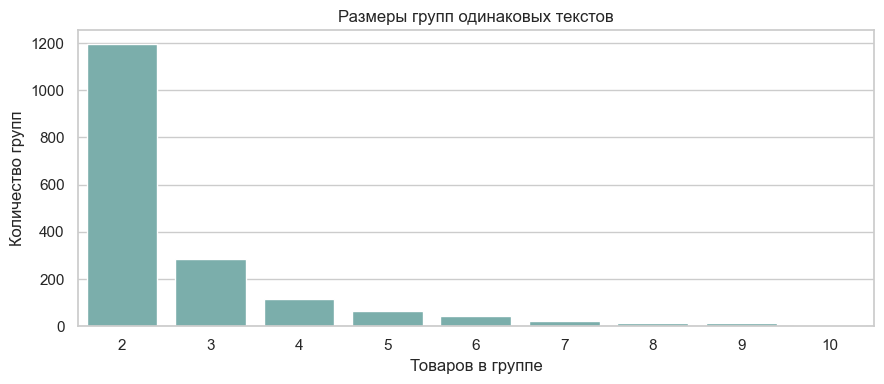

In [50]:
group_size_counts = duplicate_groups["group_size"].value_counts().sort_index()
small_group_counts = group_size_counts[group_size_counts.index <= 10]

plt.figure(figsize=(9, 4))
sns.barplot(x=small_group_counts.index, y=small_group_counts.values, color="#72B7B2")
plt.title("Размеры групп одинаковых текстов")
plt.xlabel("Товаров в группе")
plt.ylabel("Количество групп")
plt.tight_layout()
plt.show()

In [51]:
conflict_texts = set(conflict_groups["text_normalized"])
conflict_examples = df[df["text_normalized"].isin(conflict_texts)].copy()
conflict_examples = conflict_examples.sort_values(["text_normalized", "label", "id"])

columns_to_show = ["id", "category", "label", "name_clean"]
display(conflict_examples[columns_to_show].head(12))

,id,category,label,name_clean
3681,5208,БАД,0,21st Century Биотин 5000 мкг
10615,15095,БАД,1,21st Century Биотин 5000 мкг
1237,1741,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
1710,2451,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
2234,3193,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
2377,3391,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
5644,8042,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
10896,15491,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
11802,16744,БАД,0,Core Champs; RDX Pre-workout; 420g; Предтреник
6810,9658,БАД,1,Core Champs; RDX Pre-workout; 420g; Предтреник


**Вывод.** 5 399 товаров входят в 1 802 группы одинаковых нормализованных текстов; максимальная группа содержит 58 карточек. В 55 группах встречаются разные метки, при этом дубли не пересекают категории. Одинаковые тексты нужно держать в одной части train/validation, иначе оценка получится завышенной. Конфликтующие группы полезно отдельно проверить на шум разметки.

## Итог и следующий шаг

1. Таблица технически чистая: уникальные `id`, почти нет пустых текстов, у всех товаров есть изображения.
2. Главная особенность — противоположный дисбаланс меток в двух категориях.
3. Текст достаточно подробный и отличается между группами, поэтому первый baseline можно строить на названии и описании.
4. Дублей много, и их обязательно нужно учитывать при разбиении.
5. Изображения стоит добавлять только после измерения качества текста.

### Простой план развития

- сделать одно фиксированное разбиение с сохранением `category × label` и группировкой дублей;
- обучить TF-IDF + логистическую регрессию;
- посчитать F1 отдельно для двух категорий;
- вручную посмотреть самые уверенные ошибки;
- затем по одной гипотезе добавлять изображения, OCR или VLM.